In [42]:
import pandas as pd

In [43]:
import numpy as np

In [44]:
import matplotlib.pyplot as plt

In [45]:
import seaborn as sns

In [46]:
%matplotlib inline

In [47]:
df = pd.read_csv("/Users/senuja/Jupyter Notebook/Video_Game_Sales_Predictor/data/cleaned/3. Scaling/Scaling(One-Hot).csv")

In [48]:
df.head()

,Game Title,Critic Score,Sales,North American Sales,Japanese Sales,EU Sales,Other Sales,Release Year,Genre_Action-Adventure,Genre_Adventure,...,Developer_Other,Developer_Sega,Developer_Square Enix,Developer_THQ,Developer_Traveller's Tales,Developer_Ubisoft,Developer_Ubisoft Montreal,Developer_Unknown,Developer_Vicarious Visions,Developer_Visual Concepts
0,Grand Theft Auto V,0.933333,1.000000,0.652664,0.464789,1.000000,1.000000,2013,False,False,...,True,False,False,False,False,False,False,False,False,False
1,Grand Theft Auto V,0.966667,0.953740,0.620902,0.281690,0.985787,0.967949,2014,False,False,...,True,False,False,False,False,False,False,False,False,False
2,Grand Theft Auto: Vice City,0.955556,0.794291,0.861680,0.220657,0.557360,0.570513,2002,False,False,...,True,False,False,False,False,False,False,False,False,False
3,Grand Theft Auto V,0.677988,0.780512,0.928279,0.028169,0.541117,0.455128,2013,False,False,...,True,False,False,False,False,False,False,False,False,False
4,Call of Duty: Black Ops 3,0.788889,0.742126,0.633197,0.192488,0.614213,0.782051,2015,False,False,...,True,False,False,False,False,False,False,False,False,False


In [49]:
df.dtypes # check data types

Game Title                      object
Critic Score                   float64
Sales                          float64
North American Sales           float64
Japanese Sales                 float64
                                ...   
Developer_Ubisoft                 bool
Developer_Ubisoft Montreal        bool
Developer_Unknown                 bool
Developer_Vicarious Visions       bool
Developer_Visual Concepts         bool
Length: 125, dtype: object

In [50]:
# Create decade column
df['Decade'] = (df['Release Year'] // 10) * 10

# Percentages of sales per region 
df['NA Share'] = df['North American Sales'] / df['Sales']
df['EU Share'] = df['EU Sales'] / df['Sales']
df['JP Share'] = df['Japanese Sales'] / df['Sales']
df['Other Share'] = df['Other Sales'] / df['Sales']

# New Game ?
df['Is Recent'] = df['Release Year'].apply(lambda x: 1 if x >= 2015 else 0)

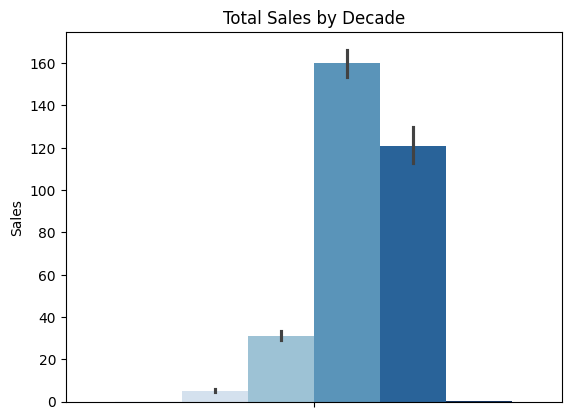

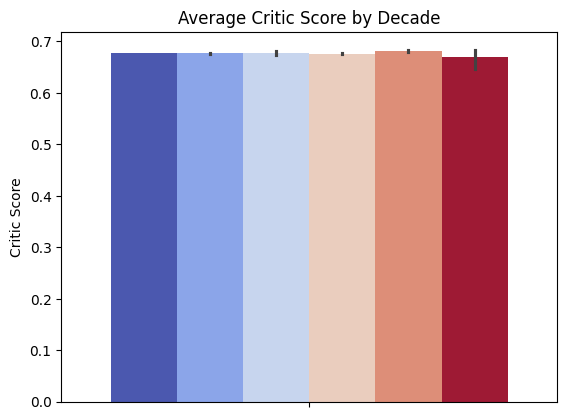

In [51]:
# Check sales trends across decades

sns.barplot(hue="Decade", y="Sales", data=df, estimator="sum", palette="Blues", legend=False)
plt.title("Total Sales by Decade")
plt.show()

sns.barplot(hue="Decade", y="Critic Score", data=df, estimator="mean", palette="coolwarm", legend=False)
plt.title("Average Critic Score by Decade")
plt.show()

In [52]:
# Bins and labels
bins = [0, 0.3, 0.7, 1.0]          # cut points
labels = ["Low", "Medium", "High"] # category names

# New Game Quality column 
df["Game Quality"] = pd.cut(df["Critic Score"], bins=bins, labels=labels, include_lowest=True)

# Label Encode categories as integers
encoding_map = {"Low": 0, "Medium": 1, "High": 2}
df["Game Quality Encoded"] = df["Game Quality"].map(encoding_map)

# check
print(df[["Critic Score", "Game Quality", "Game Quality Encoded"]].head(20))

    Critic Score Game Quality Game Quality Encoded
0       0.933333         High                    2
1       0.966667         High                    2
2       0.955556         High                    2
3       0.677988       Medium                    1
4       0.788889         High                    2
5       0.855556         High                    2
6       0.866667         High                    2
7       0.977778         High                    2
8       0.822222         High                    2
9       0.777778         High                    2
10      0.944444         High                    2
11      0.788889         High                    2
12      0.866667         High                    2
13      0.944444         High                    2
14      0.855556         High                    2
15      0.811111         High                    2
16      1.000000         High                    2
17      0.877778         High                    2
18      0.944444         High  

In [53]:
df.head()

,Game Title,Critic Score,Sales,North American Sales,Japanese Sales,EU Sales,Other Sales,Release Year,Genre_Action-Adventure,Genre_Adventure,...,Developer_Vicarious Visions,Developer_Visual Concepts,Decade,NA Share,EU Share,JP Share,Other Share,Is Recent,Game Quality,Game Quality Encoded
0,Grand Theft Auto V,0.933333,1.000000,0.652664,0.464789,1.000000,1.000000,2013,False,False,...,False,False,2010,0.652664,1.000000,0.464789,1.000000,0,High,2
1,Grand Theft Auto V,0.966667,0.953740,0.620902,0.281690,0.985787,0.967949,2014,False,False,...,False,False,2010,0.651018,1.033601,0.295353,1.014898,0,High,2
2,Grand Theft Auto: Vice City,0.955556,0.794291,0.861680,0.220657,0.557360,0.570513,2002,False,False,...,False,False,2000,1.084842,0.701708,0.277804,0.718266,0,High,2
3,Grand Theft Auto V,0.677988,0.780512,0.928279,0.028169,0.541117,0.455128,2013,False,False,...,False,False,2010,1.189320,0.693285,0.036090,0.583115,0,Medium,1
4,Call of Duty: Black Ops 3,0.788889,0.742126,0.633197,0.192488,0.614213,0.782051,2015,False,False,...,False,False,2010,0.853220,0.827640,0.259374,1.053799,1,High,2


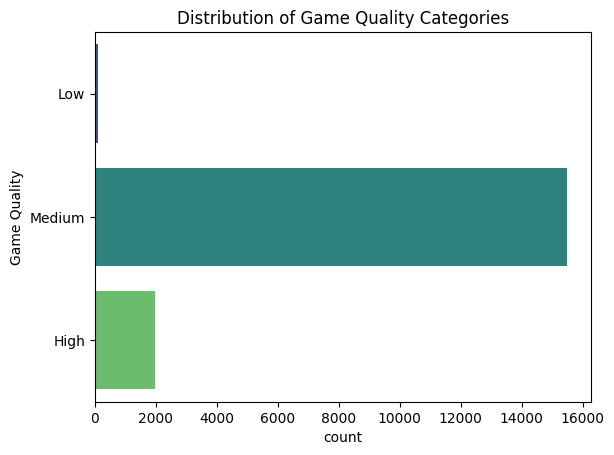

In [54]:
# Distribution of Game Quality

sns.countplot(hue="Game Quality", y="Game Quality", data=df, palette="viridis", legend=False)
plt.title("Distribution of Game Quality Categories")
plt.show()

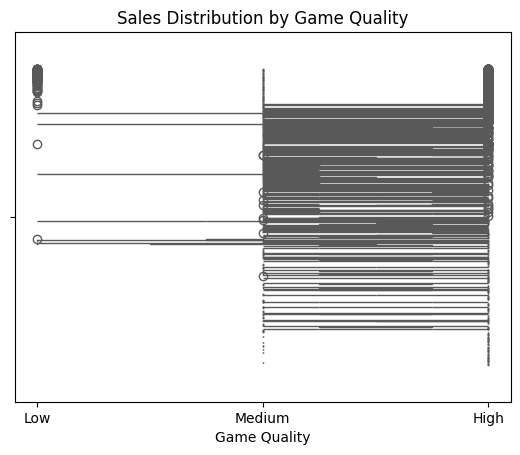

In [55]:
sns.boxplot(x="Game Quality", hue="Sales", data=df, palette="Set2", legend=False)
plt.title("Sales Distribution by Game Quality")
plt.show()

In [56]:
df.to_csv("/Users/senuja/Jupyter Notebook/Video_Game_Sales_Predictor/data/cleaned/4. Feature Engineering/Ft Engineering(One-Hot).csv", index=False)